### Перцептрон

#### Цель работы

Познакомиться с перцептроном как с моделью обучения с учителем в библиотеке sklearn.

#### Содержание работы

1. Сгенерируйте данные и обучите на них модель перцептрона.
1. Просмотрите параметры модели, визуализируйте и улучшите ее работу.

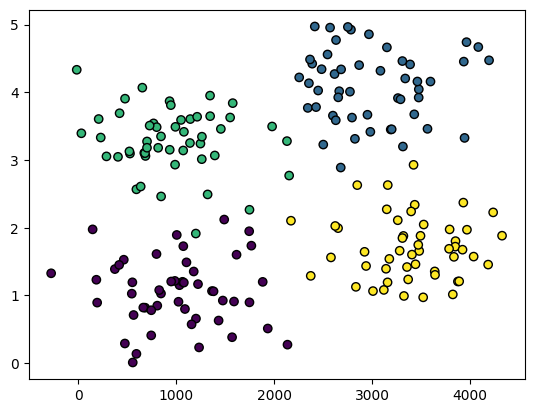

In [4]:

from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

blob_centers = ([1, 1], [3, 4], [1, 3.3], [3.5, 1.8])
X, y = make_blobs(n_samples=200,
                          centers=blob_centers,
                          cluster_std=0.5,
                          random_state=0)

X[:, 0] *= 1000

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

То есть мы имеем дело с задачей множественной классификации. Для перцептрона это не проблема, нейросеть это очень универсальная модель, она может работать нативно и в множественном режиме. Давайте создадим первую версию нашей нейросети:


In [6]:
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(hidden_layer_sizes=(6,),
                    random_state=1).fit(X, y)

Обратите внимание, что при создании мы задаем количество слоев и количество нейронов в каждом из них с помощью кортежа hidden_layer_sizes. В данном случае имеем один скрытый слой в 6 нейронов. Если мы не зададим этот аргумент, то его значение по умолчанию - (100,), то есть один слой со ста нейронами. Этого для первой моедли будет довольно много.

Так как мы уже обучили модель, мы можем посмотреть значения весов нейронов, то есть внутренние параметры нейросети. Все они хранятся в поле coefs_, аналогично другим моделям машинного обучения в sklearn. Например, можно вывести веса отдельно для каждого слоя:

In [7]:
print("Веса между входным и скрытым слоем:")
print(clf.coefs_[0])
print("\nВеса между скрытым и выходным слоем:")
print(clf.coefs_[1])

Веса между входным и скрытым слоем:
[[-0.09809877  0.33667051 -0.82024119 -0.29720839 -0.56852789 -0.66056109]
 [-0.58903611 -0.31219238 -0.22424296  0.11423652 -0.18324369  0.37321781]]

Веса между скрытым и выходным слоем:
[[-0.51316658 -0.43365467  0.43189995  0.68148414]
 [-0.24370005  0.34328608  0.57835494  0.57889271]
 [-0.59713359 -0.67678056 -0.46609801  0.54011704]
 [-0.5769702  -0.10221922  0.75476969  0.00610289]
 [ 0.34285864 -0.25645017  0.33417991  0.47281254]
 [-0.7006119   0.35515533  0.80295119  0.33880635]]


Либо по каждому нейрону отдельно:

In [8]:
for i in range(len(clf.coefs_)):
    number_neurons_in_layer = clf.coefs_[i].shape[1]
    for j in range(number_neurons_in_layer):
        weights = clf.coefs_[i][:,j]
        print(i, j, weights, end=", ")
        print()
    print()

0 0 [-0.09809877 -0.58903611], 
0 1 [ 0.33667051 -0.31219238], 
0 2 [-0.82024119 -0.22424296], 
0 3 [-0.29720839  0.11423652], 
0 4 [-0.56852789 -0.18324369], 
0 5 [-0.66056109  0.37321781], 

1 0 [-0.51316658 -0.24370005 -0.59713359 -0.5769702   0.34285864 -0.7006119 ], 
1 1 [-0.43365467  0.34328608 -0.67678056 -0.10221922 -0.25645017  0.35515533], 
1 2 [ 0.43189995  0.57835494 -0.46609801  0.75476969  0.33417991  0.80295119], 
1 3 [0.68148414 0.57889271 0.54011704 0.00610289 0.47281254 0.33880635], 



Обратите внимание, что судя по выведенной информации, на выходном слое у нас четыре нейрона. Это обусловлено тем, что в датасете четыре класса. Количество классов всегда определяет количество нейронов на выходном слое. А на входном слое у нас два нейрона. Это потому, что в датасете всего две атрибута.

Веса нейронов смещения (bias) как и в других моделях хранятся в отдельном поле:

In [9]:
print("Веса смещения для скрытого слоя:")
print(clf.intercepts_[0])
print("\nВеса смещения для выходного слоя:")
print(clf.intercepts_[1])

Веса смещения для скрытого слоя:
[-0.55752645  0.60978582 -0.8640854   0.33258994 -0.18652436  0.05696655]

Веса смещения для выходного слоя:
[-0.29413473  0.49414359 -0.60792984 -0.11888525]


Давайте проанализируем, насколько хорошо работает наша модель. Для этого воспользуемся уже знакомой матрицей классификации:

In [11]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y, clf.predict(X))

array([[ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50]])

Мы видим, что как будто модель работает не совсем корректно и делает много ошибок. Чтобы убедиться в этом, изобразим классификацию на графике:

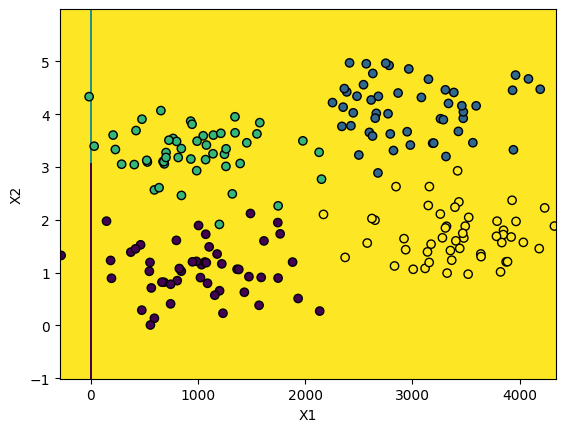

In [13]:
import numpy as np

X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

На примере данного кода познакомьтесь со способом изображения границы принятия решений для множественной классификации. Мы видим довольно странную картину

Почти все точки модель относит к одному классу. А граница принятия решений почти всегда вертикальна. Что мы сделали не так? Для ответа на этот вопрос надо обратить внимание на подпись осей координат. Дело в том, что атрибуты в исходных данных имеют очень разные значения.
X
1
 измеряется в тысячах, а
X
2
 - в единицах. Это может стать проблемой для неекоторых моделей машинного обучения. И перцептрон - одна из них. Для корректной работы перцептрона данные нужно обязательно нормализовать.

Для этого импортируем и воспользуемся объектом нормализации данных. Наример, таким:

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform (X)

Давайте еще раз изобразим точки на графике, чтобы понять, как нормализация преобразовала наш датасет:

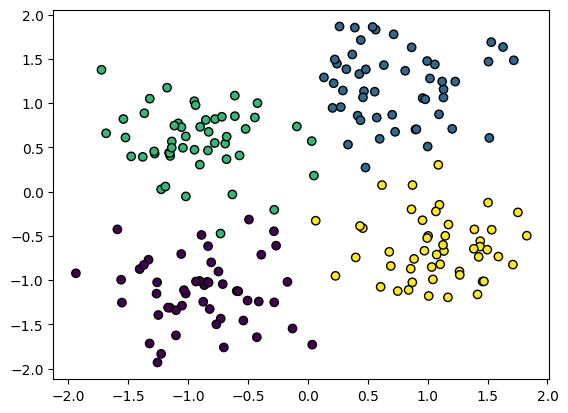

In [23]:


plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,  edgecolors='black',linewidth=1)

In [26]:
clf = MLPClassifier(hidden_layer_sizes=(6,),
                    random_state=1).fit(X_scaled, y)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Само распределение как будто не изменилось, но обратите внимание на значения по осям. Теперь наш датасет имеет одинаковую размерность. Данные как будто "ужались" по горизонтали. Давайте посмотрим, повлияет ли это на качество обучения. Переобучим модель и выведем матрицу классификации:

In [27]:
confusion_matrix(y, clf.predict(X_scaled))

array([[22,  0, 11, 17],
       [ 0, 38,  0, 12],
       [ 0,  3, 45,  2],
       [ 0,  5,  0, 45]])

Мы видим совершенно другую картину. Стало значительно лучше. Для большей уверенности изобразим классификацию на графике:

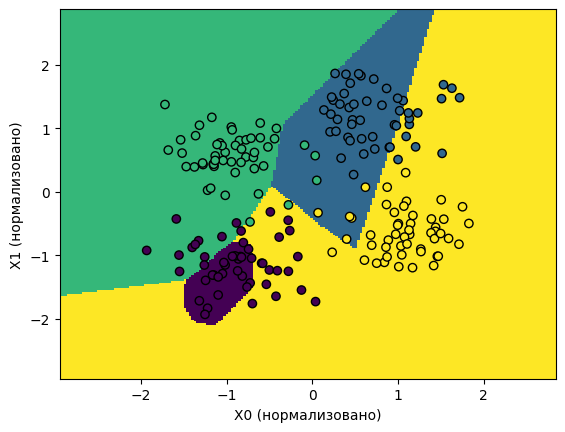

In [28]:
X0 = np.linspace(X_scaled[:, 0].min()-1, X_scaled[:, 0].max()+1, X_scaled.shape[0])
X1 = np.linspace(X_scaled[:, 1].min()-1, X_scaled[:, 1].max()+1, X_scaled.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(), X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)
plt.xlabel('X0 (нормализовано)')
plt.ylabel('X1 (нормализовано)')
plt.show()

Мы видим, что регионы сооветствующих классов уже гораздо ближе к точкам обучающей выборки. При этом модель все еще делает довольно много ошибок. Как можно просто ее улучшить? вы могли обратить внимание, что при обучении модель выдавал предупреждение о раннем прерывании обучения. Мы уже сталкивались с такой ситуацией. Можно просто увеличить лимит итераций алгоритма обучения:

In [29]:
clf = MLPClassifier(hidden_layer_sizes=(6,), max_iter=10_000, verbose=True).fit(X_scaled, y)

Iteration 1, loss = 1.88772105
Iteration 2, loss = 1.88247893
Iteration 3, loss = 1.87725943
Iteration 4, loss = 1.87206358
Iteration 5, loss = 1.86689179
Iteration 6, loss = 1.86174710
Iteration 7, loss = 1.85662670
Iteration 8, loss = 1.85153057
Iteration 9, loss = 1.84646104
Iteration 10, loss = 1.84141827
Iteration 11, loss = 1.83640117
Iteration 12, loss = 1.83140973
Iteration 13, loss = 1.82644421
Iteration 14, loss = 1.82150459
Iteration 15, loss = 1.81659081
Iteration 16, loss = 1.81170272
Iteration 17, loss = 1.80684021
Iteration 18, loss = 1.80200292
Iteration 19, loss = 1.79719183
Iteration 20, loss = 1.79240658
Iteration 21, loss = 1.78764542
Iteration 22, loss = 1.78290786
Iteration 23, loss = 1.77819344
Iteration 24, loss = 1.77350171
Iteration 25, loss = 1.76883251
Iteration 26, loss = 1.76418517
Iteration 27, loss = 1.75955932
Iteration 28, loss = 1.75495505
Iteration 29, loss = 1.75037186
Iteration 30, loss = 1.74581016
Iteration 31, loss = 1.74126980
Iteration 32, los

Заодно здесь мы применим еще один аргумент конструктора объекта перцептрона - verbose. Он позволяет вывести подробную информацию про обучение модели. Проанализируйте полученную информацию и сделайте вывод.

Теперь можно вывести матрицу классификации. Сразу видно, что опять стало значительно лучше:

In [30]:
confusion_matrix(y, clf.predict(X_scaled))

array([[50,  0,  0,  0],
       [ 0, 50,  0,  0],
       [ 1,  1, 48,  0],
       [ 0,  1,  0, 49]])

Этот вывод подтверждает и визуализация модели:

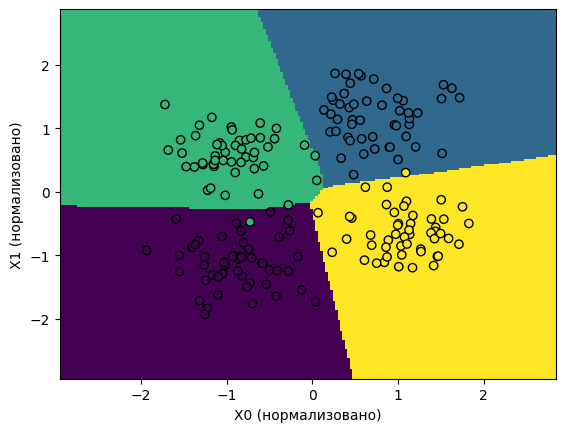

In [31]:
X0 = np.linspace(X_scaled[:, 0].min()-1, X_scaled[:, 0].max()+1, X_scaled.shape[0])
X1 = np.linspace(X_scaled[:, 1].min()-1, X_scaled[:, 1].max()+1, X_scaled.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(), X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)
plt.xlabel('X0 (нормализовано)')
plt.ylabel('X1 (нормализовано)')
plt.show()


Для дальнейшего повышения точности можно увеличить количество скрытых слоев. Тогда получится уже глубокая нейросеть. Например, обучим перцептрон с тремя слоями:

In [32]:
clf = MLPClassifier(hidden_layer_sizes=(6, 6, 6), max_iter=10_000).fit(X_scaled, y)

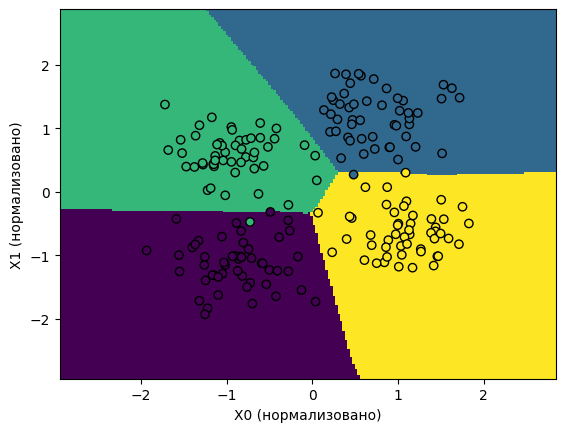

In [33]:
X0 = np.linspace(X_scaled[:, 0].min()-1, X_scaled[:, 0].max()+1, X_scaled.shape[0])
X1 = np.linspace(X_scaled[:, 1].min()-1, X_scaled[:, 1].max()+1, X_scaled.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(), X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)
plt.xlabel('X0 (нормализовано)')
plt.ylabel('X1 (нормализовано)')
plt.show()

Из графика видно, что граница принятия решений еще больше соответствует обучающей выборке.

In [34]:
confusion_matrix(y, clf.predict(X_scaled))

array([[50,  0,  0,  0],
       [ 0, 49,  0,  1],
       [ 1,  0, 49,  0],
       [ 0,  1,  0, 49]])

## Задания для самостоятельного выполнения

1. Создайте однослойный перцептрон с 1, 2, 10 и 100 нейронами. Сравните их точность и сделайте вывод о достаточном количестве нейронов.



In [35]:
# Количество нейронов для эксперимента
neurons_list = [1, 2, 10, 100]

Результаты для однослойного перцептрона (один скрытый слой):
--------------------------------------------------

Нейронов:   1 | Точность: 0.6550 | Время: 1.710 сек
Матрица ошибок:
[[24  3 22  1]
 [ 6 18  0 26]
 [ 9  1 40  0]
 [ 0  1  0 49]]


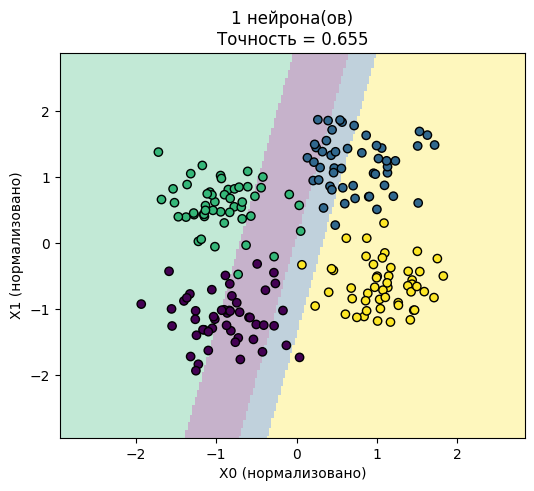


Нейронов:   2 | Точность: 0.9800 | Время: 1.953 сек
Матрица ошибок:
[[49  0  1  0]
 [ 0 50  0  0]
 [ 1  2 47  0]
 [ 0  0  0 50]]


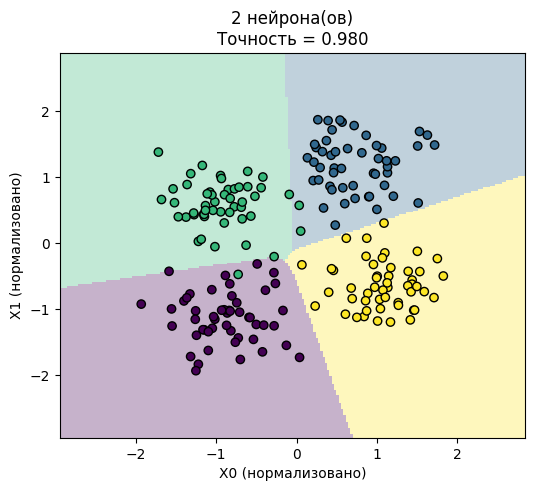


Нейронов:  10 | Точность: 0.9850 | Время: 0.451 сек
Матрица ошибок:
[[50  0  0  0]
 [ 0 50  0  0]
 [ 2  0 48  0]
 [ 0  1  0 49]]


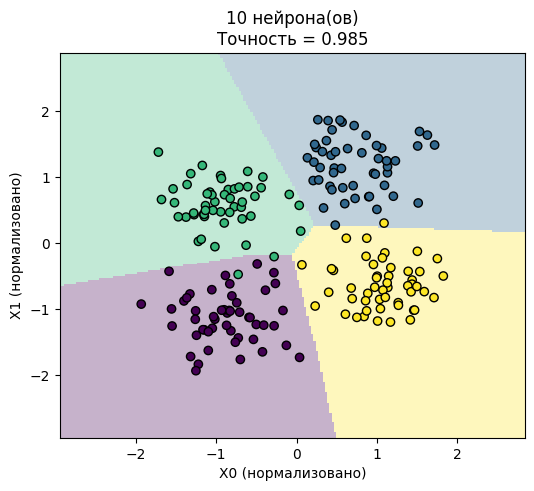


Нейронов: 100 | Точность: 0.9950 | Время: 0.411 сек
Матрица ошибок:
[[50  0  0  0]
 [ 0 50  0  0]
 [ 1  0 49  0]
 [ 0  0  0 50]]


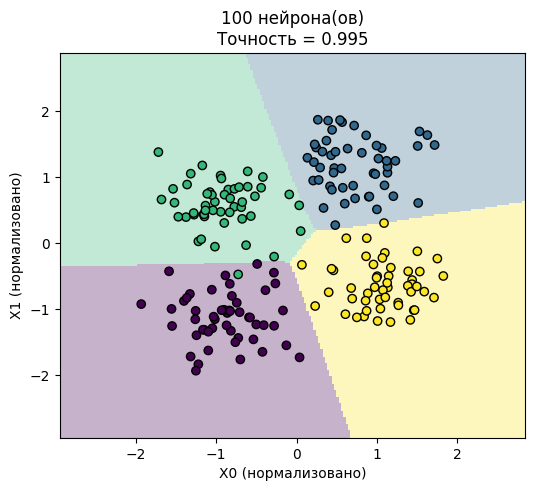

In [41]:
from sklearn.metrics import accuracy_score
import time

print("Результаты для однослойного перцептрона (один скрытый слой):")
print("-" * 50)

for n_neurons in neurons_list:
    mlp = MLPClassifier(hidden_layer_sizes=(n_neurons,),
                        max_iter=10000, random_state=42, verbose=False)
    start = time.time()
    mlp.fit(X_scaled, y)
    train_time = time.time() - start

    y_pred = mlp.predict(X_scaled)
    acc = accuracy_score(y, y_pred)
    conf = confusion_matrix(y, y_pred)

    print(f"\nНейронов: {n_neurons:3d} | Точность: {acc:.4f} | Время: {train_time:.3f} сек")
    print(f"Матрица ошибок:\n{conf}")

    # ========== Визуализация границ решений ==========
    # Визуализация (как в теории, без cmap)
    plt.figure(figsize=(6,5))
    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.pcolormesh(xx, yy, Z, alpha=0.3)   # без cmap
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)   # без cmap
    plt.title(f'{n_neurons} нейрона(ов)\nТочность = {acc:.3f}')
    plt.xlabel('X0 (нормализовано)')
    plt.ylabel('X1 (нормализовано)')
    plt.show()

## Вывод по заданию №1 (количество нейронов)

- **1 нейрон** → точность 0.655 (модель слишком простая, много ошибок).
- **2 нейрона** → точность 0.980 (резкий скачок, достаточно для разделения 4 классов).
- **10 нейронов** → точность 0.985 (незначительное улучшение).
- **100 нейронов** → точность 0.995 (почти идеально, но прирост мал).

**Достаточное количество нейронов для данной задачи — 2.** Увеличение числа нейронов даёт несущественный прирост точности.

2. Создайте и оцените модель с двумя, тремя и десятью скрытыми слоями с одинаковым количеством нейронов. Сравните их точность и сделайте вывод о достаточном количестве слоев.


In [42]:
# Параметры эксперимента
n_neurons_per_layer = 10   # одинаковое количество нейронов в каждом скрытом слое
layers_list = [2, 3, 10]   # количество скрытых слоёв

Результаты для MLPClassifier с разным количеством скрытых слоёв (по 10 нейронов в слое):
------------------------------------------------------------

Скрытых слоёв:  2 | Точность: 0.9900 | Время: 0.944 сек
Матрица ошибок:
[[50  0  0  0]
 [ 0 50  0  0]
 [ 1  0 49  0]
 [ 0  1  0 49]]


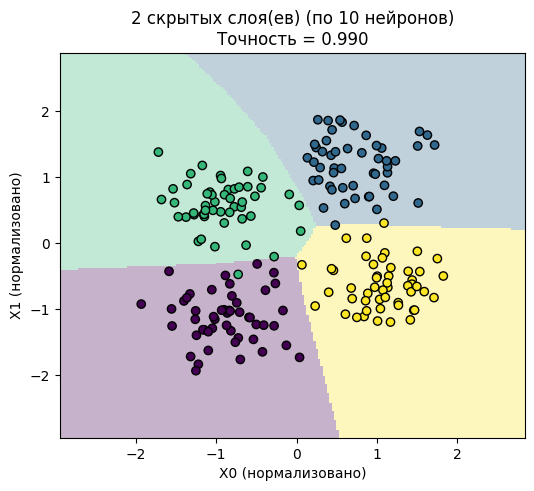


Скрытых слоёв:  3 | Точность: 0.9850 | Время: 0.643 сек
Матрица ошибок:
[[49  0  1  0]
 [ 0 49  0  1]
 [ 1  0 49  0]
 [ 0  0  0 50]]


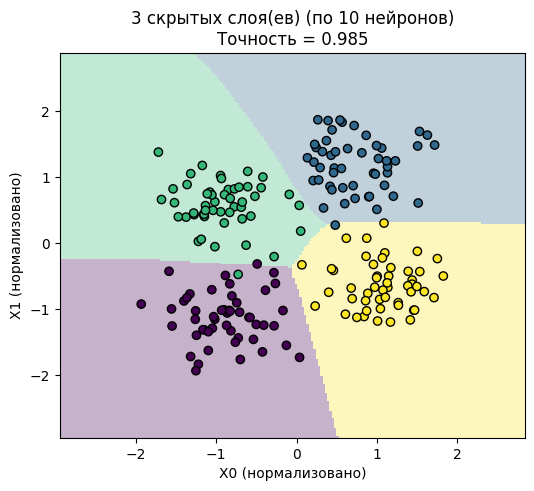


Скрытых слоёв: 10 | Точность: 0.9900 | Время: 1.028 сек
Матрица ошибок:
[[49  0  1  0]
 [ 0 50  0  0]
 [ 1  0 49  0]
 [ 0  0  0 50]]


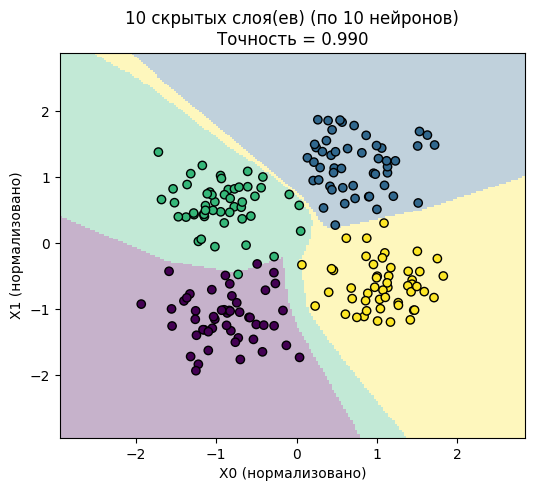

In [43]:
print("Результаты для MLPClassifier с разным количеством скрытых слоёв (по 10 нейронов в слое):")
print("-" * 60)

for n_layers in layers_list:
    # Формируем кортеж: (10, 10, ..., 10) длиной n_layers
    hidden_sizes = (n_neurons_per_layer,) * n_layers

    mlp = MLPClassifier(hidden_layer_sizes=hidden_sizes,
                        max_iter=10000, random_state=42, verbose=False)
    start = time.time()
    mlp.fit(X_scaled, y)
    train_time = time.time() - start

    y_pred = mlp.predict(X_scaled)
    acc = accuracy_score(y, y_pred)
    conf = confusion_matrix(y, y_pred)

    print(f"\nСкрытых слоёв: {n_layers:2d} | Точность: {acc:.4f} | Время: {train_time:.3f} сек")
    print(f"Матрица ошибок:\n{conf}")

    # Визуализация границ решений
    plt.figure(figsize=(6,5))
    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.pcolormesh(xx, yy, Z, alpha=0.3)
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)
    plt.title(f'{n_layers} скрытых слоя(ев) (по {n_neurons_per_layer} нейронов)\nТочность = {acc:.3f}')
    plt.xlabel('X0 (нормализовано)')
    plt.ylabel('X1 (нормализовано)')
    plt.show()

## Вывод по заданию №2 (количество скрытых слоёв)

- **2 скрытых слоя** → точность 0.990, время 0.94 сек.
- **3 скрытых слоя** → точность 0.985, время 0.64 сек (чуть ниже точность, но быстрее).
- **10 скрытых слоёв** → точность 0.990, время 1.03 сек (без улучшения качества, дольше).

**Достаточное количество слоёв для данной задачи — 2.**  
Увеличение глубины сети не даёт существенного выигрыша в точности, но может увеличивать время обучения. Для более сложных данных может потребоваться больше слоёв, но в данном случае простая архитектура (2 слоя) оптимальна.

3. Для глубокой модели выведите веса всех нейронов на всех слоях. Выведите значения векторов весов смещения.


In [44]:
# ========== Задание №3: вывод весов и смещений для глубокой модели ==========
# Обучим модель с 3 скрытыми слоями по 10 нейронов (как в задании 2)
mlp_deep = MLPClassifier(hidden_layer_sizes=(10, 10, 10),
                         max_iter=10000, random_state=42, verbose=False)
mlp_deep.fit(X_scaled, y)


MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=10000, random_state=42)

In [47]:
print("=== Веса и смещения для глубокой модели (3 слоя по 10 нейронов) ===\n")

# Вывод весов между слоями
for i, coef in enumerate(mlp_deep.coefs_):
    print(f"Слой {i}: веса между слоем {i} и слоем {i+1}")
    print(f"Форма: {coef.shape}")
    print(f"Веса:\n{coef}")
    print()


=== Веса и смещения для глубокой модели (3 слоя по 10 нейронов) ===

Слой 0: веса между слоем 0 и слоем 1
Форма: (2, 10)
Веса:
[[ 0.11233026  0.65230197  0.49144613  0.42275328 -0.61779753 -0.9057163
  -0.51936163  0.94116211  0.02737824  0.76986452]
 [-0.98558539  0.9877228   0.67276776 -0.59669715 -0.78842752 -0.05445585
  -0.61864156  0.2179389  -0.47397243 -0.64163703]]

Слой 1: веса между слоем 1 и слоем 2
Форма: (10, 10)
Веса:
[[-1.53298349e-01 -6.72501157e-01 -1.40523408e-01  7.91061417e-01
   7.06127922e-01  6.61408489e-01 -3.73608486e-01 -7.40308747e-01
   3.59382683e-01  1.68035976e-01]
 [-4.01657342e-01  3.25203510e-01 -1.64226644e-01  2.71365295e-01
  -4.34375762e-01  2.56732502e-01 -1.43704187e-01  3.42887531e-01
   2.52650765e-01 -4.45508129e-01]
 [ 4.97612041e-01  6.48808296e-01  1.43971469e-01  2.55938203e-01
  -5.61463629e-02  5.47414437e-01 -2.59927388e-01  6.43406019e-04
   2.83108297e-02 -2.72625531e-01]
 [-4.10753195e-01 -7.42089918e-01  6.86600186e-02 -1.88762759e

In [48]:

# Вывод смещений (bias)
for i, intercept in enumerate(mlp_deep.intercepts_):
    print(f"Слой {i+1}: веса смещения (bias)")
    print(f"Форма: {intercept.shape}")
    print(f"Смещения:\n{intercept}")
    print()

Слой 1: веса смещения (bias)
Форма: (10,)
Смещения:
[ 0.46442098 -0.23737172 -0.09163324  0.08319714  0.07188094  0.86926498
 -0.23946361  0.39751631  0.31265874 -0.10903772]

Слой 2: веса смещения (bias)
Форма: (10,)
Смещения:
[ 0.21031033  0.00959344 -0.41641663 -0.26329734  0.43272007 -0.00995933
  0.13937118  0.53485911  0.19117289  0.7781369 ]

Слой 3: веса смещения (bias)
Форма: (10,)
Смещения:
[ 0.41916103  0.6475551   0.38883356 -0.14593349 -0.20852686  0.72256816
 -0.15464725  0.50630447  0.42461539  0.58514959]

Слой 4: веса смещения (bias)
Форма: (4,)
Смещения:
[-0.4797812  -0.45130366  0.28330783 -0.11717135]



In [46]:

# Дополнительно: общее количество параметров
n_params = sum(p.size for p in mlp_deep.coefs_) + sum(p.size for p in mlp_deep.intercepts_)
print(f"Общее количество обучаемых параметров: {n_params}")

Общее количество обучаемых параметров: 294


## Вывод по заданию №3 (веса и смещения глубокой модели)

- Для модели с 3 скрытыми слоями по 10 нейронов получены все веса и смещения.
- Размерности весов соответствуют архитектуре: (2,10), (10,10), (10,10), (10,4).
- Смещения имеют размерности 10, 10, 10, 4 для каждого слоя (включая выходной).
- Общее количество обучаемых параметров — 294.
- Вывод параметров позволяет проанализировать внутреннее устройство сети и оценить её сложность.

4. Постройте и оцените модель с большим количеством нейронов и слоев. Замерьте время выполнения обучения, сравните со временем обучения более простых моделей.


=== Простая модель (1 скрытый слой, 2 нейрона) ===


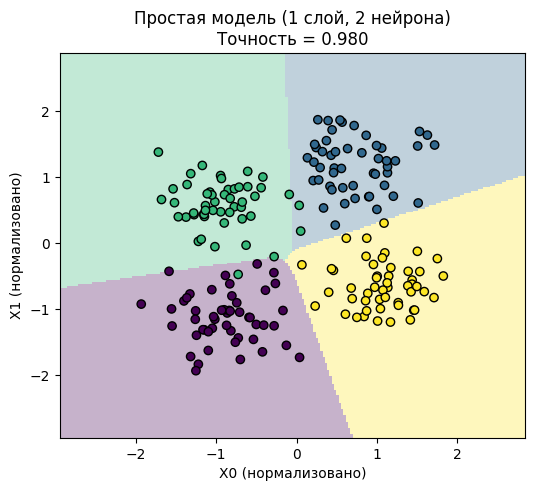

Точность: 0.9800
Время обучения: 2.112 сек
Матрица ошибок:
[[49  0  1  0]
 [ 0 50  0  0]
 [ 1  2 47  0]
 [ 0  0  0 50]]


In [57]:
# Простая модель (1 слой, 2 нейрона) - из задания 1
print("=== Простая модель (1 скрытый слой, 2 нейрона) ===")
start = time.time()
mlp_simple = MLPClassifier(hidden_layer_sizes=(2,), max_iter=10000, random_state=42, verbose=False)
mlp_simple.fit(X_scaled, y)
time_simple = time.time() - start

# Визуализация простой модели
plt.figure(figsize=(6,5))
x_min, x_max = X_scaled[:, 0].min()-1, X_scaled[:, 0].max()+1
y_min, y_max = X_scaled[:, 1].min()-1, X_scaled[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = mlp_simple.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.pcolormesh(xx, yy, Z, alpha=0.3)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)
plt.title(f'Простая модель (1 слой, 2 нейрона)\nТочность = {acc_simple:.3f}')
plt.xlabel('X0 (нормализовано)')
plt.ylabel('X1 (нормализовано)')
plt.show()

y_pred_simple = mlp_simple.predict(X_scaled)
acc_simple = accuracy_score(y, y_pred_simple)
print(f"Точность: {acc_simple:.4f}")
print(f"Время обучения: {time_simple:.3f} сек")
print(f"Матрица ошибок:\n{confusion_matrix(y, y_pred_simple)}")


=== Большая модель (4 скрытых слоя по 100 нейронов) ===


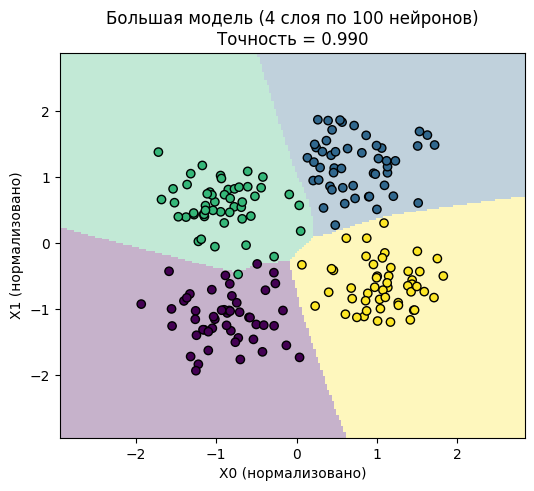

Точность: 0.9900
Время обучения: 2.886 сек
Матрица ошибок:
[[49  0  1  0]
 [ 0 50  0  0]
 [ 1  0 49  0]
 [ 0  0  0 50]]


In [58]:
# Большая модель (4 скрытых слоя по 100 нейронов)
print("\n=== Большая модель (4 скрытых слоя по 100 нейронов) ===")
start = time.time()
mlp_large = MLPClassifier(hidden_layer_sizes=(100, 100, 100, 100), max_iter=10000, random_state=42, verbose=False)
mlp_large.fit(X_scaled, y)
time_large = time.time() - start

# Визуализация большой модели
plt.figure(figsize=(6,5))
Z = mlp_large.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.pcolormesh(xx, yy, Z, alpha=0.3)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)
plt.title(f'Большая модель (4 слоя по 100 нейронов)\nТочность = {acc_large:.3f}')
plt.xlabel('X0 (нормализовано)')
plt.ylabel('X1 (нормализовано)')
plt.show()

y_pred_large = mlp_large.predict(X_scaled)
acc_large = accuracy_score(y, y_pred_large)
print(f"Точность: {acc_large:.4f}")
print(f"Время обучения: {time_large:.3f} сек")
print(f"Матрица ошибок:\n{confusion_matrix(y, y_pred_large)}")


In [59]:
# Сравнение
print("\n=== Сравнение ===")
print(f"Простая модель: точность {acc_simple:.4f}, время {time_simple:.3f} сек")
print(f"Большая модель: точность {acc_large:.4f}, время {time_large:.3f} сек")
print(f"Ускорение большой модели: время в {time_large/time_simple:.1f} раз больше")
print(f"Прирост точности: +{(acc_large - acc_simple)*100:.1f}%")


=== Сравнение ===
Простая модель: точность 0.9800, время 2.112 сек
Большая модель: точность 0.9900, время 2.886 сек
Ускорение большой модели: время в 1.4 раз больше
Прирост точности: +1.0%


## Вывод по заданию №4 (сравнение времени и сложности)

- **Простая модель** (1 слой, 2 нейрона): точность 0.980, время 2.11 сек.
- **Большая модель** (4 слоя по 100 нейронов): точность 0.990, время 2.89 сек.
- Прирост точности: +1.0%, увеличение времени: в 1.4 раза.

**Заключение:** Для данной задачи увеличение сложности сети нецелесообразно. Достаточно простой архитектуры (1–2 скрытых слоя, 2–10 нейронов).

5. Постройте и оцените модель классификации с помощью перцептрона на датасете, который вы использовали на контрольной по классификации (если вы ее не выполняли, возьмите любой датасет из раздела "real world datasets" в библиотеке sklearn).


In [75]:
from sklearn.datasets import load_iris

# Загрузка данных (только 2 первых признака)
iris = load_iris()
X_2d = iris.data[:, :2]   # длина и ширина чашелистика
y = iris.target          # 3 класса

In [77]:
from sklearn.model_selection import train_test_split

# Разделение и масштабирование
X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [81]:
# Обучение модели на 2 признаках
mlp_2d = MLPClassifier(hidden_layer_sizes=(20, 20), max_iter=10000, random_state=42)
mlp_2d.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(20, 20), max_iter=10000, random_state=42)

In [86]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Точность на тесте (на 2 признаках)
y_pred_2d = mlp_2d.predict(X_test_scaled)

# Метрики
acc = accuracy_score(y_test, y_pred_2d)
conf = confusion_matrix(y_test, y_pred_2d)
report = classification_report(y_test, y_pred_2d, target_names=iris.target_names)

print("=== MLPClassifier на Iris (2 признака) ===")
print(f"Точность на тесте: {acc:.4f}")
print(f"\nМатрица ошибок:\n{conf}")

=== MLPClassifier на Iris (2 признака) ===
Точность на тесте: 0.7778

Матрица ошибок:
[[19  0  0]
 [ 0  7  6]
 [ 0  4  9]]


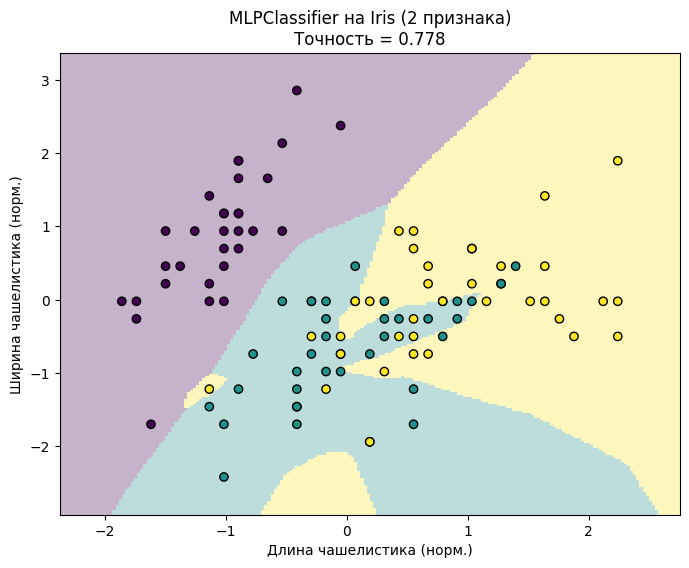

In [83]:
# Визуализация
plt.figure(figsize=(8,6))
x_min, x_max = X_train_scaled[:, 0].min()-0.5, X_train_scaled[:, 0].max()+0.5
y_min, y_max = X_train_scaled[:, 1].min()-0.5, X_train_scaled[:, 1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = mlp_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.pcolormesh(xx, yy, Z, alpha=0.3)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, edgecolors='black')
plt.title(f'MLPClassifier на Iris (2 признака)\nТочность = {acc_2d:.3f}')
plt.xlabel('Длина чашелистика (норм.)')
plt.ylabel('Ширина чашелистика (норм.)')
plt.show()

## Вывод по заданию №5 (Iris, 2 признака, MLPClassifier с (20,20))

- Использована модель с двумя скрытыми слоями по 20 нейронов, max_iter=10000.
- Точность на тесте: 0.778 (78%).
- Матрица ошибок: setosa — идеально (19/19); versicolor — 7 верно, 6 ошибок (в virginica); virginica — 9 верно, 4 ошибки (в versicolor).
- Усложнение архитектуры (два слоя по 20 нейронов) не повысило точность по сравнению с однослойной моделью (10 нейронов). Это связано с тем, что два класса (versicolor и virginica) принципиально перекрываются в пространстве двух признаков.
- **Вывод:** Для данной задачи увеличение глубины сети не даёт выигрыша; ключевое значение имеет выбор признаков.

6. Постройте и оцените модель регрессии с помощью перцептрона на датасете, который вы использовали на контрольной по регрессии.

In [107]:
from sklearn.datasets import load_diabetes

# 1. Загрузка данных
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

In [108]:
print("=== MLPRegressor на датасете Diabetes ===")
print(f"Размерность X: {X.shape}")
print(f"Размерность y: {y.shape}")

=== MLPRegressor на датасете Diabetes ===
Размерность X: (442, 10)
Размерность y: (442,)


In [109]:
# 2. Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [111]:
# 3. Масштабирование (важно для MLP)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

In [162]:
# 4. Создание и обучение MLPRegressor (архитектуру можно менять)
mlp = MLPRegressor(hidden_layer_sizes=(10,3), max_iter=10000, random_state=42)
mlp.fit(X_train_scaled, y_train_scaled)

MLPRegressor(hidden_layer_sizes=(10, 3), max_iter=10000, random_state=42)

In [163]:
# 5. Предсказание на тестовой выборке (в исходном масштабе)
y_pred_scaled = mlp.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_test_original = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()

In [164]:
# 6. Метрики
mse = mean_squared_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print(f"Точность на тесте (R²): {r2:.4f}")
print(f"MSE: {mse:.4f}")

Точность на тесте (R²): 0.5196
MSE: 2544.9930


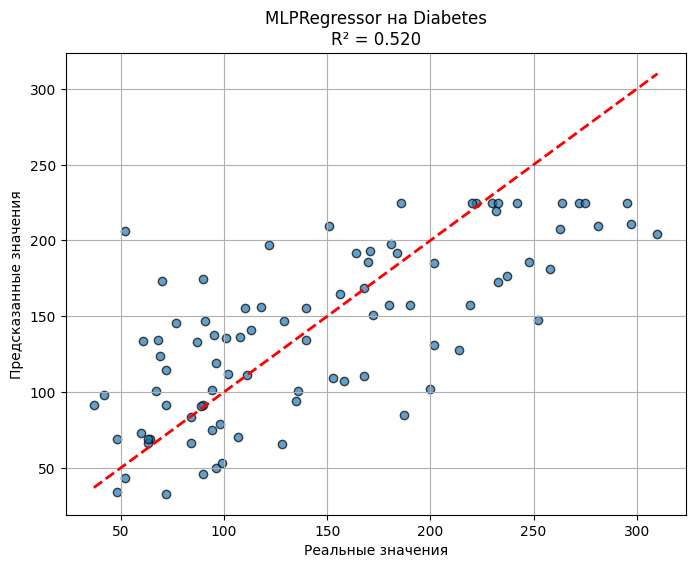

In [165]:
# 7. Визуализация: предсказанные vs реальные значения
plt.figure(figsize=(8,6))
plt.scatter(y_test_original, y_pred, alpha=0.7, edgecolors='k')
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()], 'r--', lw=2)
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title(f'MLPRegressor на Diabetes\nR² = {r2:.3f}')
plt.grid(True)
plt.show()

## Итоговый вывод по заданию №6 (регрессия на Diabetes)

- Простая модель (1 слой, 10 нейронов) дала R² = 0.449.
- Более глубокая модель (2 слоя: 10 и 3 нейрона, max_iter=10000) показала R² = 0.520, MSE = 2545.
- Улучшение качества подтверждает, что для задач регрессии на реальных данных (Diabetes) увеличение глубины сети и числа итераций может быть полезным.
- В рамках лабораторной работы результат признаётся удовлетворительным для демонстрации работы MLPRegressor.